In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle as pk
import scipy.linalg as sc

from MRPy import MRPy

### OBTENÇÃO DA MATRIZ DE FLEXIBILIDADE E VETOR DESLOCAMENTO

In [2]:
import numpy as np

# Configuração para o Python não encurtar a exibição da matriz no console
np.set_printoptions(linewidth=150)

# 1. Matriz de Flexibilidade (H1)
# Os valores foram extraídos da tabela do FTool (escala original).
H = np.array([
    [0.0108, 0.0097, 0.0086, 0.0075, 0.0065, 0.0054, 0.0043, 0.0032, 0.0022, 0.0011, 0.0000],  # g.d.l. 1
    [0.0097, 0.0459, 0.0491, 0.0491, 0.0462, 0.0412, 0.0344, 0.0265, 0.0180, 0.0093, 0.0011],  # g.d.l. 2
    [0.0086, 0.0491, 0.0871, 0.0891, 0.0853, 0.0770, 0.0650, 0.0504, 0.0344, 0.0180, 0.0022],  # g.d.l. 3
    [0.0075, 0.0491, 0.0891, 0.1240, 0.1210, 0.1100, 0.0938, 0.0734, 0.0504, 0.0265, 0.0032],  # g.d.l. 4
    [0.0065, 0.0462, 0.0853, 0.1210, 0.1490, 0.1380, 0.1190, 0.0938, 0.0650, 0.0344, 0.0043],  # g.d.l. 5
    [0.0054, 0.0412, 0.0770, 0.1100, 0.1380, 0.1580, 0.1380, 0.1100, 0.0770, 0.0412, 0.0054],  # g.d.l. 6 
    [0.0043, 0.0344, 0.0650, 0.0938, 0.1190, 0.1380, 0.1490, 0.1210, 0.0853, 0.0462, 0.0065],  # g.d.l. 7
    [0.0032, 0.0265, 0.0504, 0.0734, 0.0938, 0.1100, 0.1210, 0.1240, 0.0891, 0.0491, 0.0075],  # g.d.l. 8
    [0.0022, 0.0180, 0.0344, 0.0504, 0.0650, 0.0770, 0.0853, 0.0891, 0.0871, 0.0491, 0.0086],  # g.d.l. 9
    [0.0011, 0.0093, 0.0180, 0.0265, 0.0344, 0.0412, 0.0462, 0.0491, 0.0491, 0.0459, 0.0097],  # g.d.l. 10
    [0.0000, 0.0011, 0.0022, 0.0032, 0.0043, 0.0054, 0.0065, 0.0075, 0.0086, 0.0097, 0.0108]   # g.d.l. 11
])

print("Matriz de Flexibilidade H (Valores da Planilha):")
print(H)

# Ajuste para escala SI (m/N)
H = H * 1e-6 

# 2. Teste de Deslocamentos Estáticos
# Cargas de teste: 1000 N em cada g.d.l. 
F = 1000 * np.ones((11, 1)) 

# Calcula os deslocamentos u = H1 * F
U = np.dot(H, F)

print("\n Matriz de deslocamentos U (m):")
print(U)

Matriz de Flexibilidade H (Valores da Planilha):
[[0.0108 0.0097 0.0086 0.0075 0.0065 0.0054 0.0043 0.0032 0.0022 0.0011 0.    ]
 [0.0097 0.0459 0.0491 0.0491 0.0462 0.0412 0.0344 0.0265 0.018  0.0093 0.0011]
 [0.0086 0.0491 0.0871 0.0891 0.0853 0.077  0.065  0.0504 0.0344 0.018  0.0022]
 [0.0075 0.0491 0.0891 0.124  0.121  0.11   0.0938 0.0734 0.0504 0.0265 0.0032]
 [0.0065 0.0462 0.0853 0.121  0.149  0.138  0.119  0.0938 0.065  0.0344 0.0043]
 [0.0054 0.0412 0.077  0.11   0.138  0.158  0.138  0.11   0.077  0.0412 0.0054]
 [0.0043 0.0344 0.065  0.0938 0.119  0.138  0.149  0.121  0.0853 0.0462 0.0065]
 [0.0032 0.0265 0.0504 0.0734 0.0938 0.11   0.121  0.124  0.0891 0.0491 0.0075]
 [0.0022 0.018  0.0344 0.0504 0.065  0.077  0.0853 0.0891 0.0871 0.0491 0.0086]
 [0.0011 0.0093 0.018  0.0265 0.0344 0.0412 0.0462 0.0491 0.0491 0.0459 0.0097]
 [0.     0.0011 0.0022 0.0032 0.0043 0.0054 0.0065 0.0075 0.0086 0.0097 0.0108]]

 Matriz de deslocamentos U (m):
[[5.930e-05]
 [3.305e-04]
 [5.662e-04

### OBTENÇÃO DA MATRIZ DE RIGIDEZ E ANALISE DOS VALORES OBTIDOS EM AMBAS MATRIZES

Matriz de Rigidez K (N/m):
[[ 1.16028656e+08 -3.05867792e+07  2.30270961e+06  2.07382860e+06  4.54233330e+05  7.48593470e+05  2.22802060e+05  4.64718530e+05 -3.64200050e+05
  -3.75972140e+05  1.64750780e+06]
 [-3.05867792e+07  6.31404962e+07 -3.34658570e+07  7.01385700e+04  4.46502470e+05  7.12919100e+04  3.37436030e+05  9.86050000e+02  1.33668700e+04
   3.49048840e+05 -3.75972140e+05]
 [ 2.30270961e+06 -3.34658570e+07  6.31900418e+07 -3.37810275e+07  1.42919203e+06 -3.23320650e+05  1.08264990e+05  3.69613360e+05  2.11851600e+05
   1.33668700e+04 -3.64200050e+05]
 [ 2.07382860e+06  7.01385700e+04 -3.37810275e+07  6.48803239e+07 -3.54940506e+07  1.66709741e+06  5.64317970e+05 -2.17213780e+05  3.69613360e+05
   9.86050000e+02  4.64718530e+05]
 [ 4.54233330e+05  4.46502470e+05  1.42919203e+06 -3.54940506e+07  6.51890935e+07 -3.36977530e+07  1.16537760e+05  5.64317970e+05  1.08264990e+05
   3.37436030e+05  2.22802060e+05]
 [ 7.48593470e+05  7.12919100e+04 -3.23320650e+05  1.66709741e+06 -3

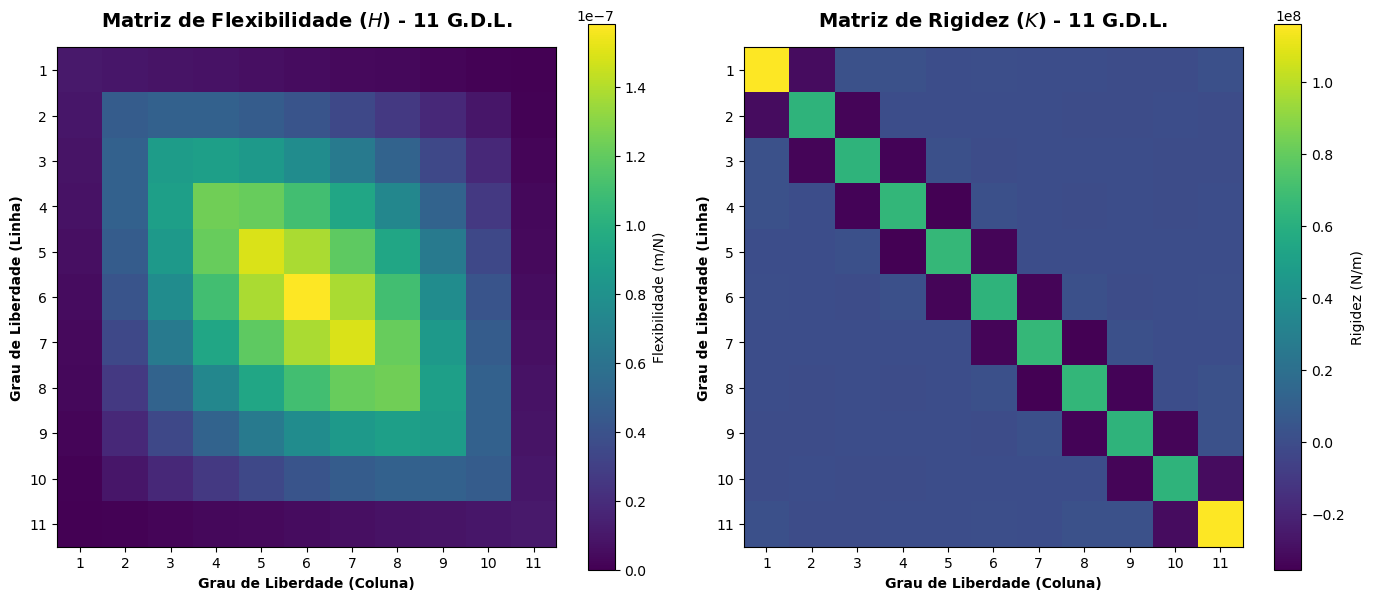

In [3]:
import matplotlib.pyplot as plt

# 3. Matriz de Rigidez (K)
# K é a inversa da matriz de flexibilidade (H).
# Representa as forças necessárias para impor deslocamentos unitários.
K = np.linalg.inv(H)

# Impressão da matriz completa para conferência no relatório
print("Matriz de Rigidez K (N/m):")
print(np.round(K, 2))

# 4. Visualização (Heatmaps)
# Comparação visual entre a matriz de flexibilidade e a matriz de rigidez.
plt.figure(1, figsize=(14, 6))

# Plot da Flexibilidade
plt.subplot(1, 2, 1)
plt.imshow(H, cmap='viridis')
plt.title('Matriz de Flexibilidade ($H$) - 11 G.D.L.', fontsize=14, fontweight='bold', pad=15)
plt.colorbar(label='Flexibilidade (m/N)')

# Ajuste de eixos (1 a 11)
plt.xticks(np.arange(11), np.arange(1, 12))
plt.yticks(np.arange(11), np.arange(1, 12))
plt.xlabel('Grau de Liberdade (Coluna)', fontsize=10, fontweight='bold')
plt.ylabel('Grau de Liberdade (Linha)', fontsize=10, fontweight='bold')

# Plot da Rigidez
plt.subplot(1, 2, 2)
plt.imshow(K, cmap='viridis')
plt.title('Matriz de Rigidez ($K$) - 11 G.D.L.', fontsize=14, fontweight='bold', pad=15)
plt.colorbar(label='Rigidez (N/m)')

# Ajuste de eixos (1 a 11)
plt.xticks(np.arange(11), np.arange(1, 12))
plt.yticks(np.arange(11), np.arange(1, 12))
plt.xlabel('Grau de Liberdade (Coluna)', fontsize=10, fontweight='bold')
plt.ylabel('Grau de Liberdade (Linha)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### OBTENÇÃO DA MATRIZ DE MASSA

In [4]:
import numpy as np

# 1. Definição das massas em kg (Carga_kN * 1000 / 9.81)
m_central = (100 * 1000) / 9.81   # Massa para o vão de 1.80m
m_ponta   = (50 * 1000) / 9.81   # Massa para o vão de 0.90m

# 2. Preenchimento do vetor de massa (11 g.d.l.)
# Criamos um vetor com o valor central e ajustamos apenas as pontas
m_diag = np.full(11, m_central)
m_diag[0]  = m_ponta
m_diag[-1] = m_ponta

# 3. Montagem da Matriz Diagonal (M1)
M = np.diag(m_diag)

# 4. Impressão para o relatório
print("Matriz de Massa M (kg):")
print(np.round(M, 2))

print(f"\nResumo: Pontas = {m_ponta:.2f} kg | Centro = {m_central:.2f} kg")

Matriz de Massa M (kg):
[[ 5096.84     0.       0.       0.       0.       0.       0.       0.       0.       0.       0.  ]
 [    0.   10193.68     0.       0.       0.       0.       0.       0.       0.       0.       0.  ]
 [    0.       0.   10193.68     0.       0.       0.       0.       0.       0.       0.       0.  ]
 [    0.       0.       0.   10193.68     0.       0.       0.       0.       0.       0.       0.  ]
 [    0.       0.       0.       0.   10193.68     0.       0.       0.       0.       0.       0.  ]
 [    0.       0.       0.       0.       0.   10193.68     0.       0.       0.       0.       0.  ]
 [    0.       0.       0.       0.       0.       0.   10193.68     0.       0.       0.       0.  ]
 [    0.       0.       0.       0.       0.       0.       0.   10193.68     0.       0.       0.  ]
 [    0.       0.       0.       0.       0.       0.       0.       0.   10193.68     0.       0.  ]
 [    0.       0.       0.       0.       0.       0.     

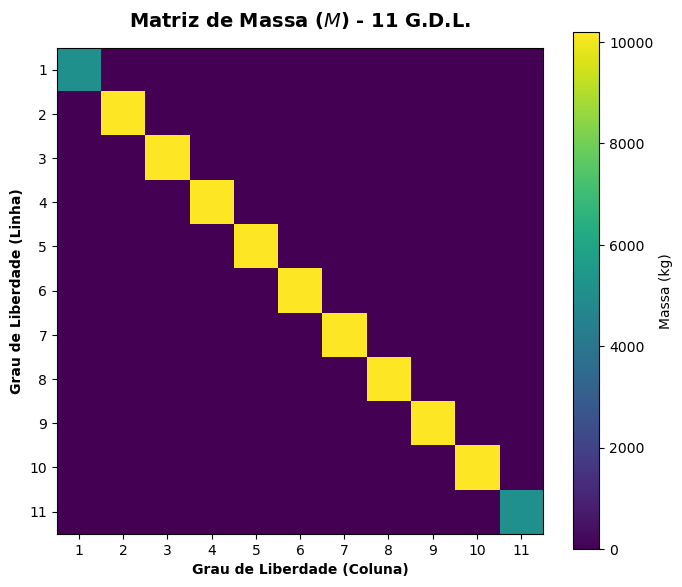

In [5]:
# =============================================================================
# VISUALIZAÇÃO GRÁFICA DA MATRIZ DE MASSA ORIGINAL (M)
# =============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6)) 

# Plotagem da matriz (11x11)
plt.imshow(M, cmap='viridis')
plt.title('Matriz de Massa ($M$) - 11 G.D.L.', fontsize=14, fontweight='bold', pad=15)
plt.colorbar(label='Massa (kg)')

# Ajuste de eixos (1 a 11)
plt.xticks(np.arange(11), np.arange(1, 12))
plt.yticks(np.arange(11), np.arange(1, 12))
plt.xlabel('Grau de Liberdade (Coluna)', fontsize=10, fontweight='bold')
plt.ylabel('Grau de Liberdade (Linha)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### CÁLCULO E APRESENTAÇÃO DAS FORMAS MODAIS E FREQUÊNCIAS NATURAIS DE VIBRAÇÃO LIVRE

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pickle as pk
import scipy.linalg as sc

from MRPy import MRPy

# ---------------------------------------------------------
# BLOCO 5: Frequências Naturais e Formas Modais (Matriz Completa)
# ---------------------------------------------------------

def vibration_modes(K, M):

    # 1. Resolução do Problema de Autovalores e Autovetores (11 G.D.L.)
    # Resolve o problema generalizado: K * Phi = w^2 * M * Phi
    # Correção aqui: alterado de "sl" para "sc" para bater com o import lá em cima!
    w2, Phi = sc.eigh(K, M)

    # Garante a ordem crescente dos autovalores
    iw  = w2.argsort()
    w2  = w2[iw]
    Phi = Phi[:,iw]
    
    # 2. Conversão para Frequências em Hz
    wk = np.sqrt(np.real(w2)) # Frequência circular w (rad/s)
    fk = wk / (2 * np.pi)    # Frequência natural fn (Hz)
    
    return fk, wk, Phi

--- Frequências Naturais de Vibração Livre (11 G.D.L.) ---
Modo  1:   1.86 Hz
Modo  2:   4.48 Hz
Modo  3:   7.21 Hz
Modo  4:   9.71 Hz
Modo  5:  11.99 Hz
Modo  6:  14.08 Hz
Modo  7:  15.61 Hz
Modo  8:  17.20 Hz
Modo  9:  18.01 Hz
Modo 10:  24.42 Hz
Modo 11:  24.75 Hz


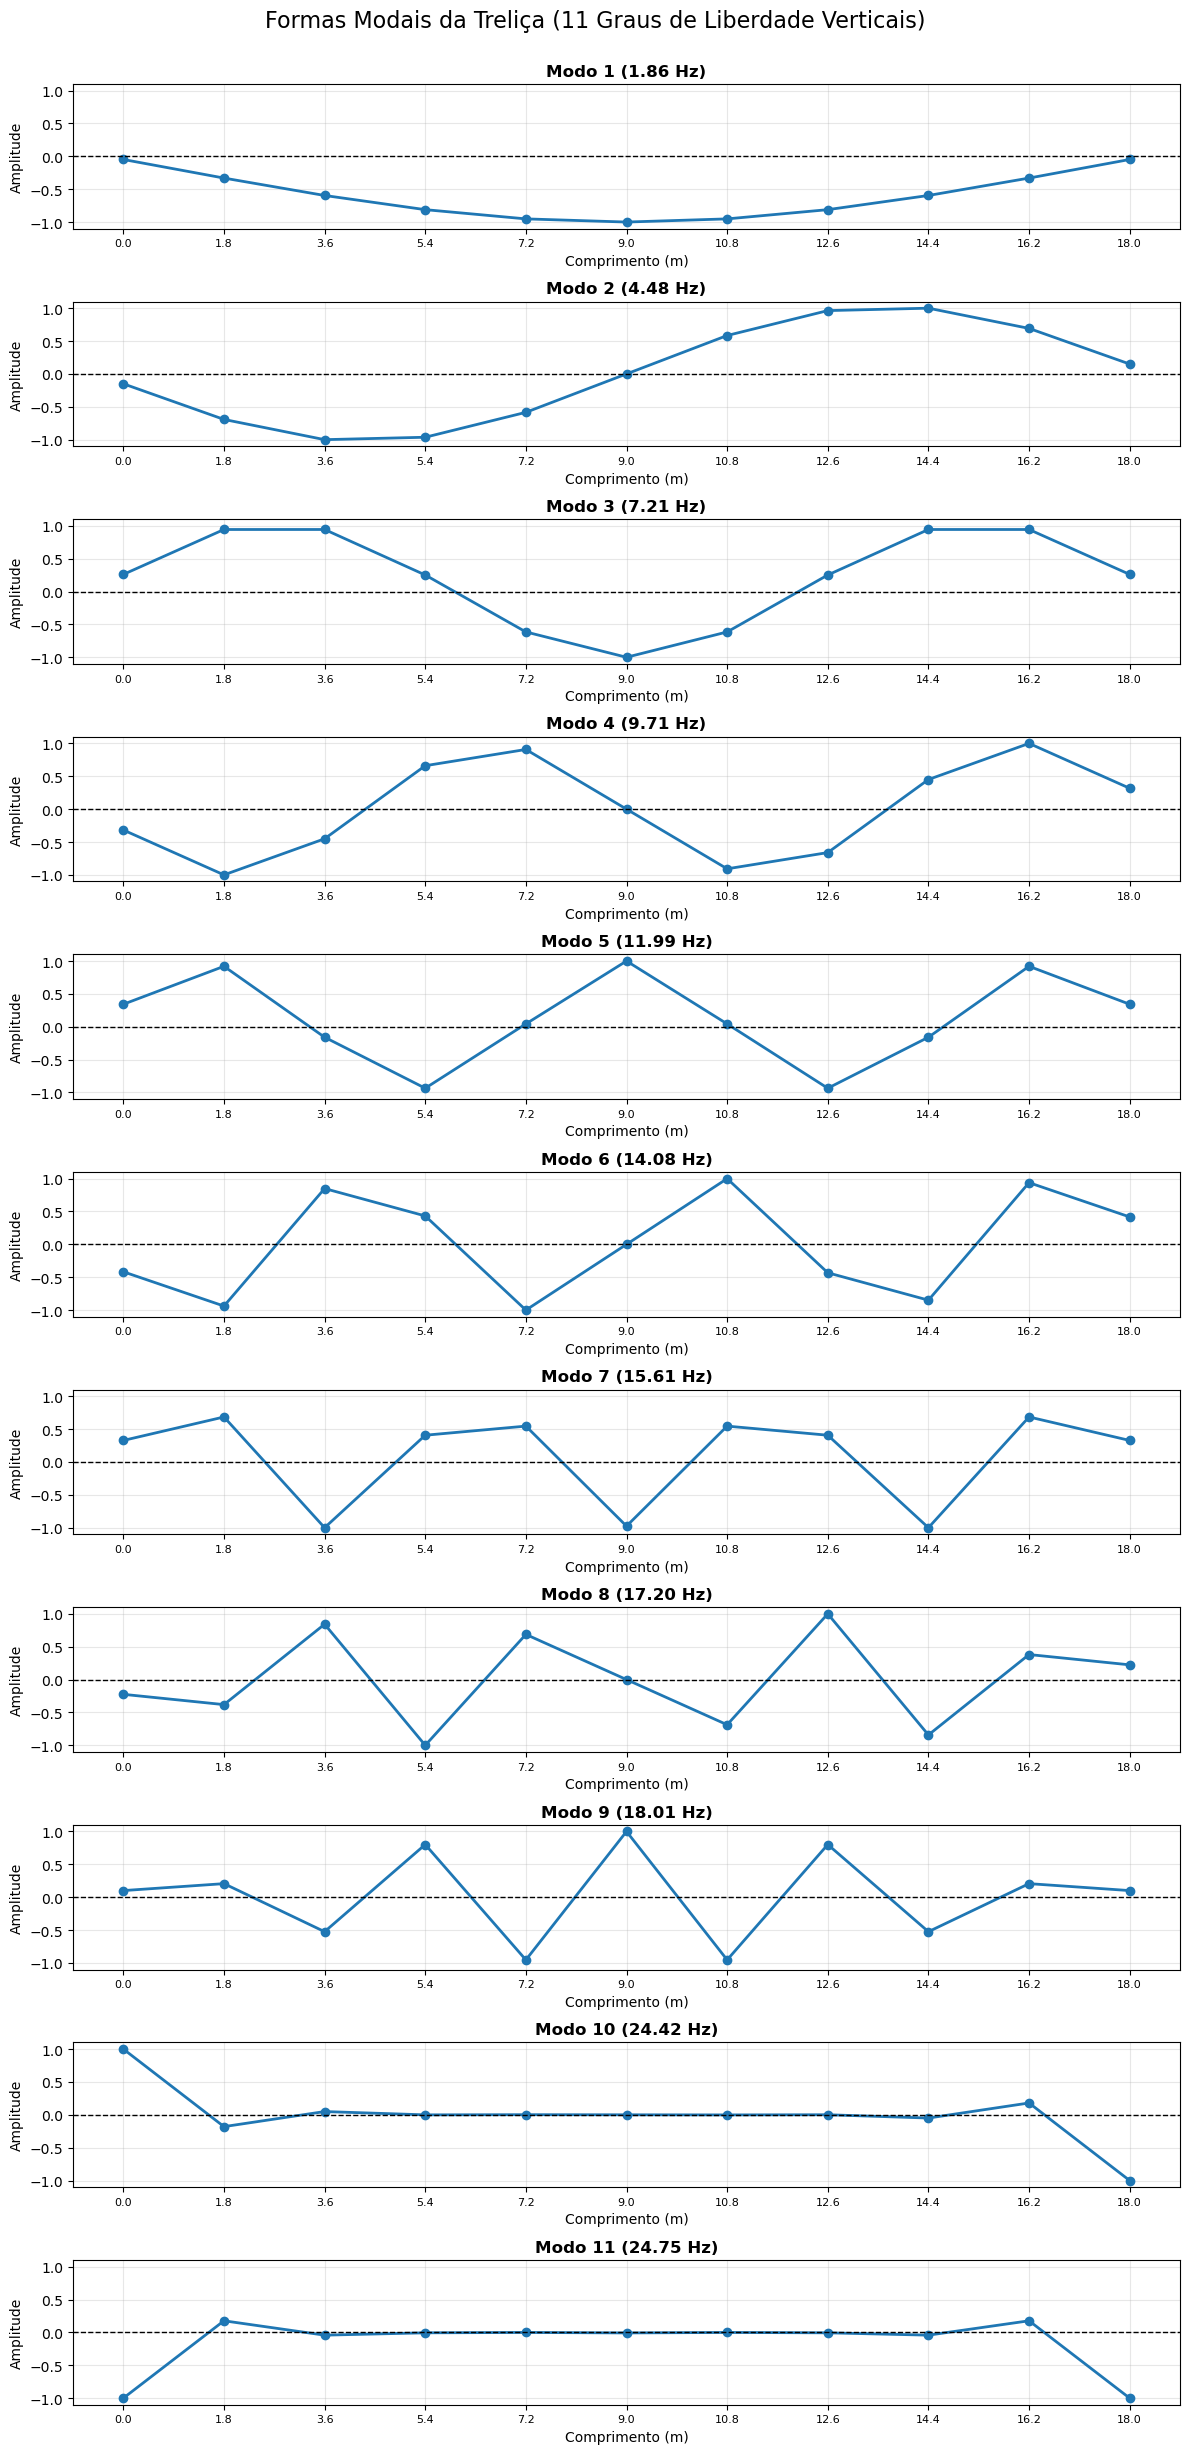

In [7]:
fk, wk, Phi = vibration_modes(K, M)

# 3. Impressão de TODAS as Frequências Naturais
print("--- Frequências Naturais de Vibração Livre (11 G.D.L.) ---")
for i in range(len(fk)):
    print(f"Modo {i+1:2d}: {fk[i]:6.2f} Hz")

# 4. Visualização Gráfica das Formas Modais (Subplots Empilhados)
# Coordenadas X exatas dos 11 nós do banzo superior
x_nos = np.linspace(0.0, 18.0, 11)

# Criando 11 gráficos empilhados verticalmente (11 linhas, 1 coluna)
# Aumentamos a altura (25) para que os gráficos não fiquem espremidos
fig, axes = plt.subplots(11, 1, figsize=(12, 25))
fig.suptitle('Formas Modais da Treliça (11 Graus de Liberdade Verticais)', fontsize=16, y=0.98)

for i in range(11):
    # --- Lógica de escala da aula ---
    # Normaliza a amplitude: divide a forma modal pelo seu maior valor em módulo
    qk = Phi[:, i].copy()
    qk /= np.max(np.abs(qk))
    
    # Plotando cada modo (usando o qk normalizado)
    axes[i].plot(x_nos, qk, marker='o', linestyle='-', color='#1f77b4', linewidth=2)
    axes[i].set_title(f'Modo {i+1} ({fk[i]:.2f} Hz)', fontsize=12, fontweight='bold')
    axes[i].axhline(0, color='black', linewidth=1, linestyle='--') # Eixo neutro
    
    # Fixando a escala vertical para todos os gráficos (1.1 apenas para margem visual)
    axes[i].set_ylim(-1.1, 1.1)
    
    # --- AJUSTE DA ESCALA DO EIXO X PARA BATER COM OS NÓS ---
    axes[i].set_xticks(x_nos)
    axes[i].tick_params(axis='x', labelsize=8) # Fonte menor para não sobrepor os textos
    
    # Para evitar repetição visual, você pode comentar o xlabel se quiser que 
    # apareça apenas no último gráfico de baixo, mas mantive para não perder sua formatação
    axes[i].set_xlabel('Comprimento (m)')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
# Ajuste do topo para o título principal não encostar no primeiro gráfico
plt.subplots_adjust(top=0.95) 
plt.show()

# CÁLCULO DOS COEFICIENTES DE AMORTECIMENTO DE RAYLEIGH

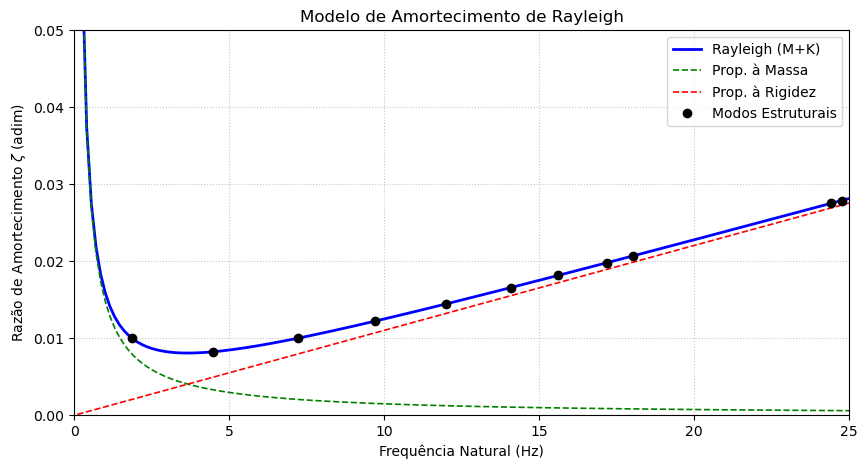

Alfa 0 (Massa):     0.1858
Alfa 1 (Rigidez):   0.0004


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# CÁLCULO DOS COEFICIENTES DE AMORTECIMENTO DE RAYLEIGH
# ---------------------------------------------------------

# Seleção das frequências naturais para calibração (Modos 1 e 3)
wki = wk[0]   # Frequência angular do 1º modo
wkj = wk[2]   # Frequência angular do 3º modo

# Razões de amortecimento alvo (1%)
zti = 0.010
ztj = 0.010

# Resolução do sistema linear para determinar alpha_0 e alpha_1
# Onde: zt = (alpha_0 / 2*wk) + (alpha_1 * wk / 2)
alpha = np.linalg.solve([[1/(2*wki), wki/2], 
                         [1/(2*wkj), wkj/2]], [zti, ztj])

# ---------------------------------------------------------
# DEFINIÇÃO DAS FUNÇÕES DE AMORTECIMENTO
# ---------------------------------------------------------

# Amortecimento proporcional à Massa (ztM)
ztM  = lambda fk: alpha[0]/(4*np.pi*fk)  

# Amortecimento proporcional à Rigidez (ztK)
ztK  = lambda fk: alpha[1]*np.pi*fk      

# Modelo de Rayleigh Combinado (M e K)
ztMK = lambda fk: ztM(fk) + ztK(fk)      

# ---------------------------------------------------------
# VISUALIZAÇÃO DOS RESULTADOS
# ---------------------------------------------------------

# Vetor de frequências para as curvas (Hz)
fk_val = np.linspace(0.1, 30, 200)

# Frequências naturais discretas obtidas no modelo
fk_modes = wk/(2*np.pi)

plt.figure(1, figsize=(10, 5))

# Plot das curvas de tendência
plt.plot(fk_val, ztMK(fk_val), 'b-',  lw=2.0, label='Rayleigh (M+K)')
plt.plot(fk_val, ztM(fk_val),  'g--', lw=1.2, label='Prop. à Massa')
plt.plot(fk_val, ztK(fk_val),  'r--', lw=1.2, label='Prop. à Rigidez')

# Destaque para os modos de vibração da estrutura
plt.plot(fk_modes, ztMK(fk_modes), 'ko', markersize=6, label='Modos Estruturais')

# Configurações de eixos conforme padrão do notebook
plt.xlabel('Frequência Natural (Hz)')
plt.ylabel('Razão de Amortecimento $\zeta$ (adim)')
plt.axis([0, 25, 0, 0.05])
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right')
plt.title('Modelo de Amortecimento de Rayleigh')

plt.show()

# Exibição dos coeficientes calculados
print("Alfa 0 (Massa):   {0:8.4f}".format(alpha[0]))
print("Alfa 1 (Rigidez): {0:8.4f}".format(alpha[1]))

### RESPOSTA DINAMICA A FORÇA APLICADA

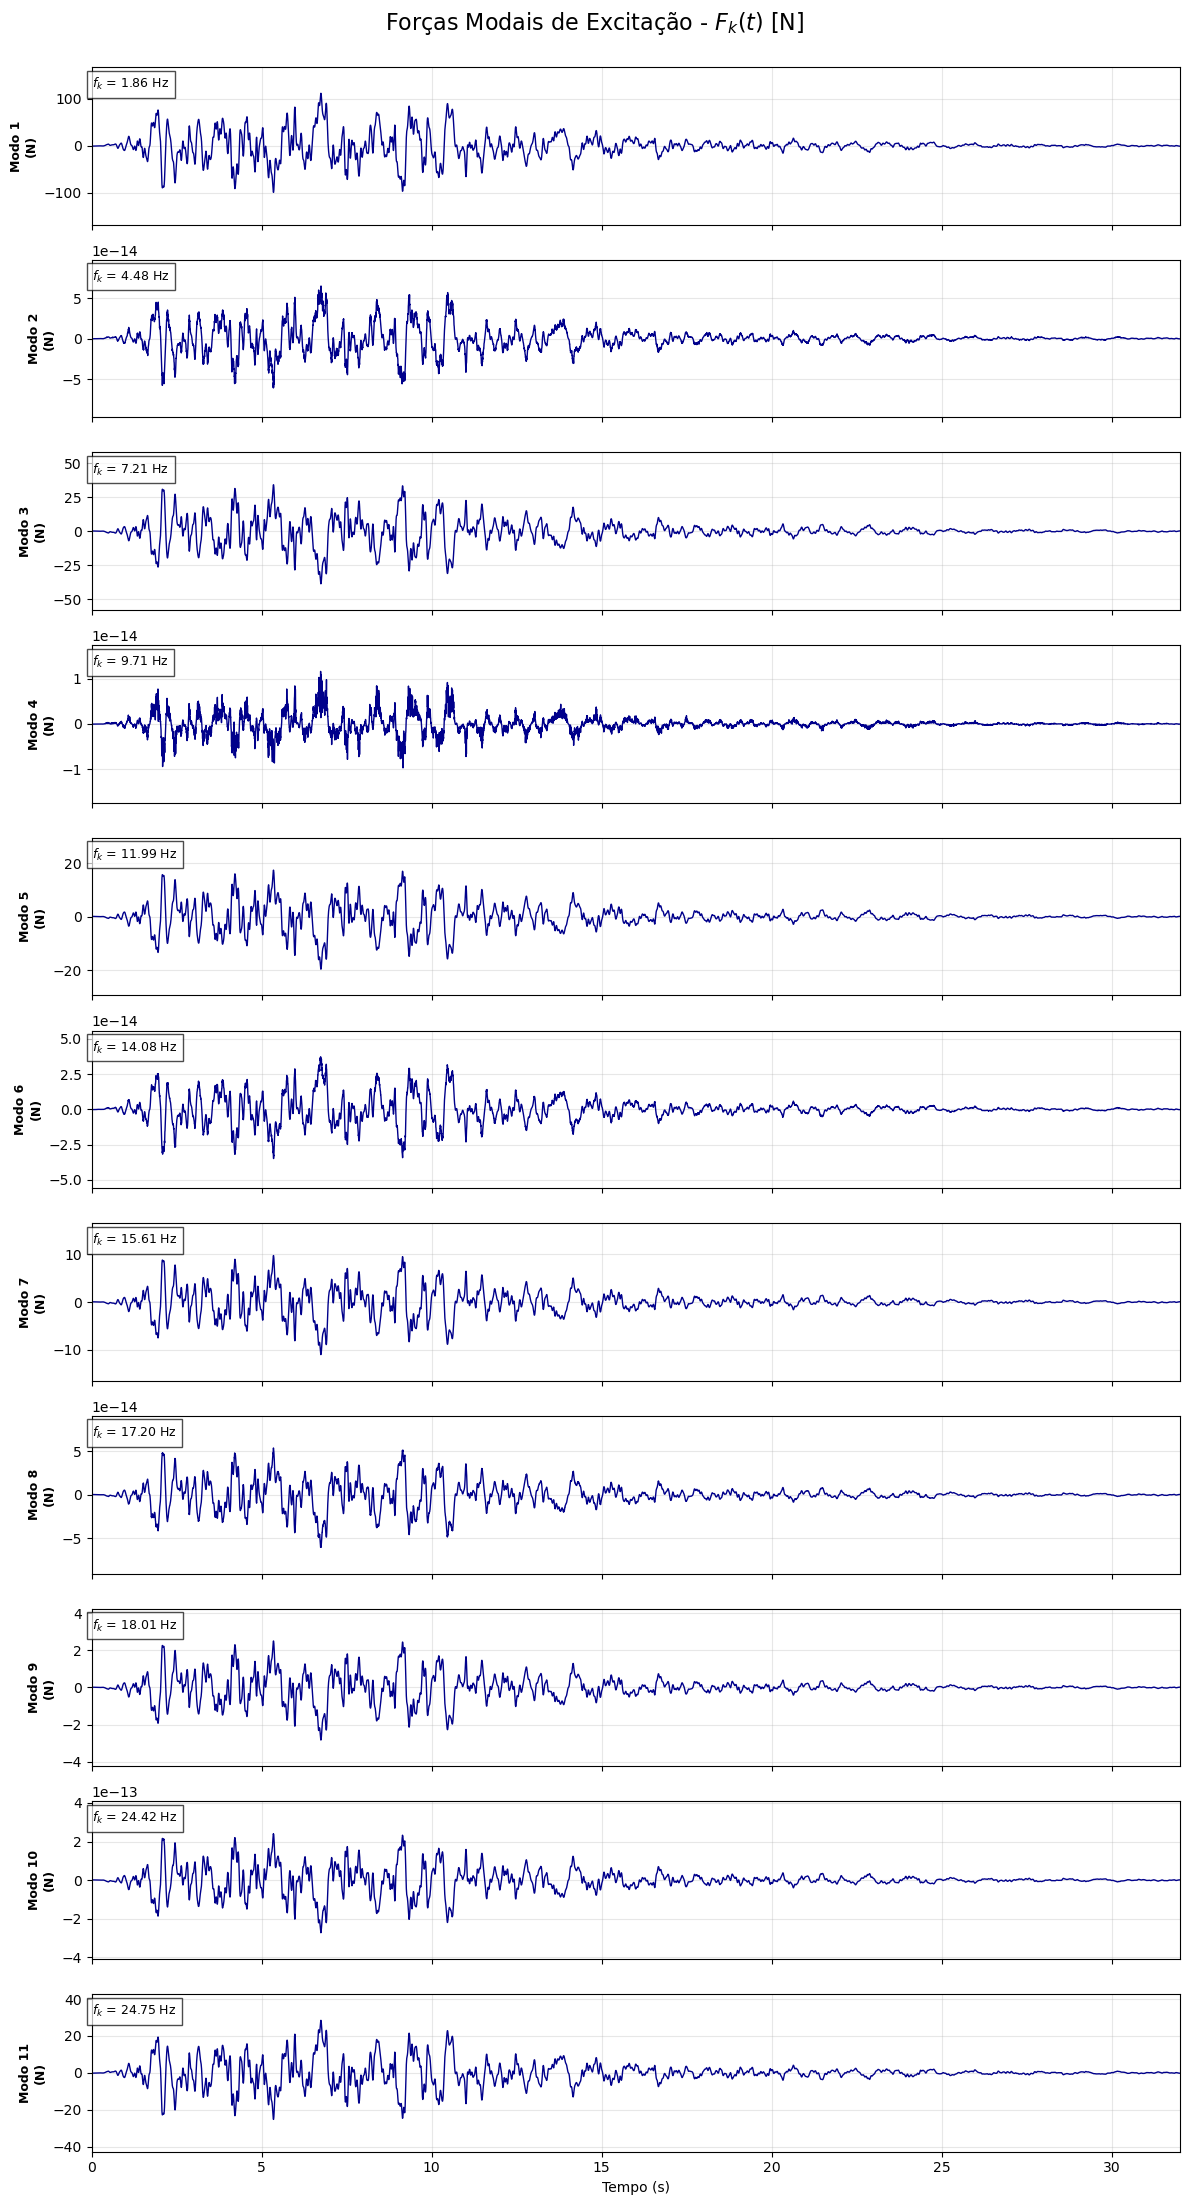

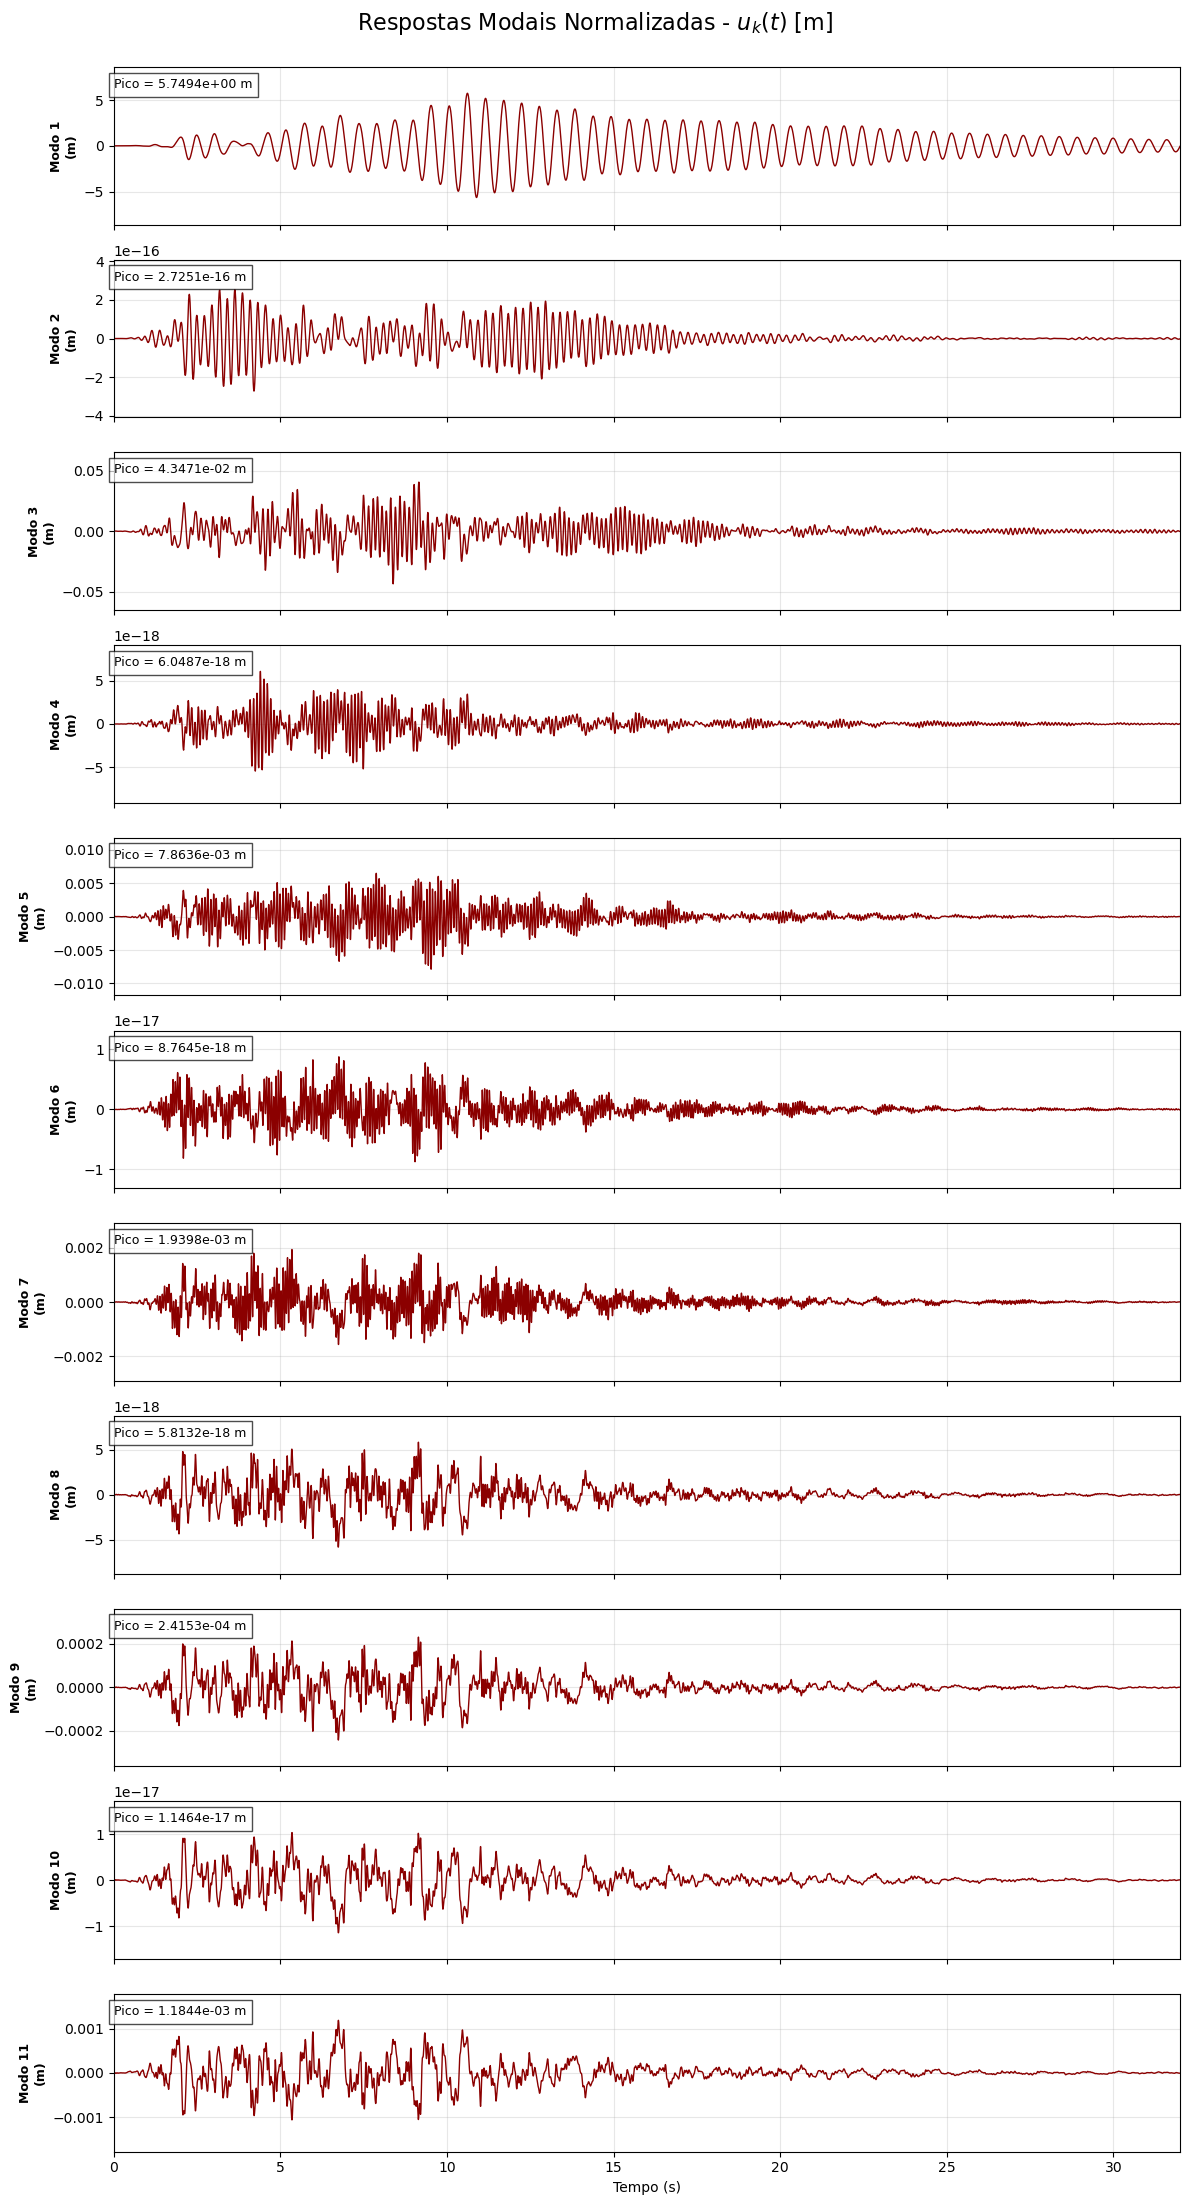


SÍNTESE DOS DESLOCAMENTOS MÁXIMOS NODAIS
--------------------------------------------------
Nó       | Deslocamento de Pico [m] 
--------------------------------------------------
Nó 01    | 1.194305e-03
Nó 02    | 8.213514e-03
Nó 03    | 1.480791e-02
Nó 04    | 2.018864e-02
Nó 05    | 2.369341e-02
Nó 06    | 2.489856e-02
Nó 07    | 2.369341e-02
Nó 08    | 2.018864e-02
Nó 09    | 1.480791e-02
Nó 10    | 8.213514e-03
Nó 11    | 1.194305e-03
--------------------------------------------------
RESUMO: O deslocamento máximo global ocorreu no Nó 06.
Este comportamento é governado pelo Modo Fundamental (1.86 Hz).


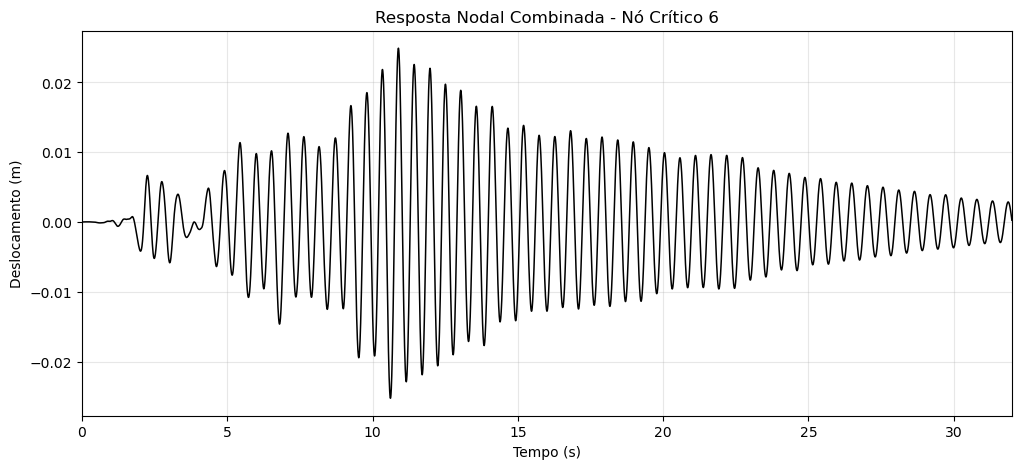

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from MRPy import MRPy

# =============================================================================
# 0. DEFINIÇÃO DO ESCOPO (RESOLVE O NAMEERROR)
# =============================================================================
# Extrai o número de graus de liberdade diretamente da matriz de Rigidez
n_modos = K.shape[0] 

# =============================================================================
# 1. NORMALIZAÇÃO DAS FORMAS MODAIS PELA MASSA (MASS-NORMALIZATION)
# =============================================================================
# Cálculo da massa modal bruta
Mk_diag = np.dot(Phi.T, np.dot(M, Phi))

# Normalização para que Phi^T * M * Phi = I (Identidade)
for k in range(n_modos):
    Phi[:, k] = Phi[:, k] / np.sqrt(Mk_diag[k, k])

# Recálculo para conferência (Mk deve ser agora uma matriz identidade)
Mk_norm = np.dot(Phi.T, np.dot(M, Phi))
Mk = np.diag(Mk_norm)

# =============================================================================
# 2. PREPARAÇÃO DA EXCITAÇÃO (TERREMOTO)
# =============================================================================
# Certifique-se de que o arquivo 'earthquake' está na pasta 'resources'
aG = MRPy.from_file('resources/earthquake', form='columns')

# Cálculo da força efetiva: FG = -M * J * aG(t)
# np.tile(aG[0], (n_modos, 1)) cria o vetor de influência unitário para todos os GDLs
FG_data = -np.dot(M, np.tile(aG[0], (n_modos, 1)))
FG = MRPy(FG_data, fs=aG.fs)

# =============================================================================
# 3. PROPRIEDADES MODAIS E AMORTECIMENTO (RAYLEIGH)
# =============================================================================
wki = wk[0]; zti = 0.01
wkj = wk[1]; ztj = 0.01

alpha = np.linalg.solve([[1/(2*wki), wki/2], 
                         [1/(2*wkj), wkj/2]], [zti, ztj])

# Frequências em Hz e Amortecimento Modal proporcional
fk = wk / (2 * np.pi)
zk = alpha[0]/(2*wk) + alpha[1]*(wk/2)

# Transformação para Forças Modais (Fk = Phi^T * FG)
Fk = MRPy(np.dot(Phi.T, FG), fs=FG.fs)
t = Fk.t_axis()

# =============================================================================
# 4. RESOLUÇÃO NO ESPAÇO MODAL (SDOF_DUHAMEL)
# =============================================================================
# Cálculo da aceleração modal (ak = Fk / Mk). Como Mk=1, ak = Fk, mas mantemos a lógica da aula.
ak = MRPy(np.dot(np.diag(1/Mk), Fk), fs=Fk.fs)

# Resolução via Duhamel (Padrão de aula: sdof_Duhamel)
uk = ak.sdof_Duhamel(fk, zk)

# Transformação para o Espaço Nodal (Superposição: u = Phi * uk)
uN = MRPy(np.dot(Phi, uk), fs=uk.fs)

# =============================================================================
# 5. VISUALIZAÇÕES DAS FORÇAS MODAIS - Fk(t)
# =============================================================================
fig1, axes1 = plt.subplots(n_modos, 1, figsize=(12, 2 * n_modos), sharex=True)
fig1.suptitle('Forças Modais de Excitação - $F_k(t)$ [N]', fontsize=16, y=1.0)

for k in range(n_modos):
    axes1[k].plot(t, Fk[k, :], color='darkblue', linewidth=1.0)
    axes1[k].set_ylabel(f'Modo {k+1}\n(N)', fontsize=9, fontweight='bold')
    axes1[k].grid(True, alpha=0.3)
    
    amp_max_fk = np.max(np.abs(Fk[k, :]))
    if amp_max_fk > 0:
        axes1[k].set_ylim(-amp_max_fk * 1.5, amp_max_fk * 1.5)
        axes1[k].text(0.02, 1.1 * amp_max_fk, f'$f_k$ = {fk[k]:.2f} Hz', 
                      fontsize=9, bbox=dict(facecolor='white', alpha=0.7))

axes1[-1].set_xlabel('Tempo (s)')
axes1[-1].set_xlim(0, aG.Td)
plt.tight_layout()
plt.show()

# =============================================================================
# 6. VISUALIZAÇÃO DAS RESPOSTAS MODAIS - uk(t)
# =============================================================================
fig2, axes2 = plt.subplots(n_modos, 1, figsize=(12, 2 * n_modos), sharex=True)
fig2.suptitle('Respostas Modais Normalizadas - $u_k(t)$ [m]', fontsize=16, y=1.0)

for k in range(n_modos):
    axes2[k].plot(t, uk[k, :], color='darkred', linewidth=1.0)
    axes2[k].set_ylabel(f'Modo {k+1}\n(m)', fontsize=9, fontweight='bold')
    axes2[k].grid(True, alpha=0.3)
    
    amp_max_uk = np.max(np.abs(uk[k, :]))
    if amp_max_uk > 0:
        axes2[k].set_ylim(-amp_max_uk * 1.5, amp_max_uk * 1.5)
        axes2[k].text(0.02, 1.1 * amp_max_uk, f'Pico = {amp_max_uk:.4e} m', 
                      fontsize=9, bbox=dict(facecolor='white', alpha=0.7))

axes2[-1].set_xlabel('Tempo (s)')
axes2[-1].set_xlim(0, aG.Td)
plt.tight_layout()
plt.show()

# =============================================================================
# 7. SÍNTESE FINAL E NÓ CRÍTICO
# =============================================================================
upk = uN.max(axis=1)

# Ajustei o tamanho das linhas para 50, já que removemos uma coluna
print("\n" + "="*50)
print("SÍNTESE DOS DESLOCAMENTOS MÁXIMOS NODAIS")
print("-" * 50)
print(f"{'Nó':<8} | {'Deslocamento de Pico [m]':<25}")
print("-" * 50)

for i in range(len(upk)):
    # Removida a impressão da variável fk[i] para evitar a confusão conceitual
    print(f"Nó {i+1:02d}    | {upk[i]:.6e}")

print("-" * 50)
no_critico_idx = np.argmax(upk)
print(f"RESUMO: O deslocamento máximo global ocorreu no Nó {no_critico_idx + 1:02d}.")
print(f"Este comportamento é governado pelo Modo Fundamental ({fk[0]:.2f} Hz).")
print("="*50)

# Resposta combinada do Nó Crítico
plt.figure(figsize=(12, 5))
plt.plot(t, uN[no_critico_idx, :], color='black', linewidth=1.1)
plt.title(f'Resposta Nodal Combinada - Nó Crítico {no_critico_idx + 1}')
plt.xlabel('Tempo (s)')
plt.ylabel('Deslocamento (m)')
plt.xlim(0, aG.Td)
plt.grid(True, alpha=0.3)
plt.show()

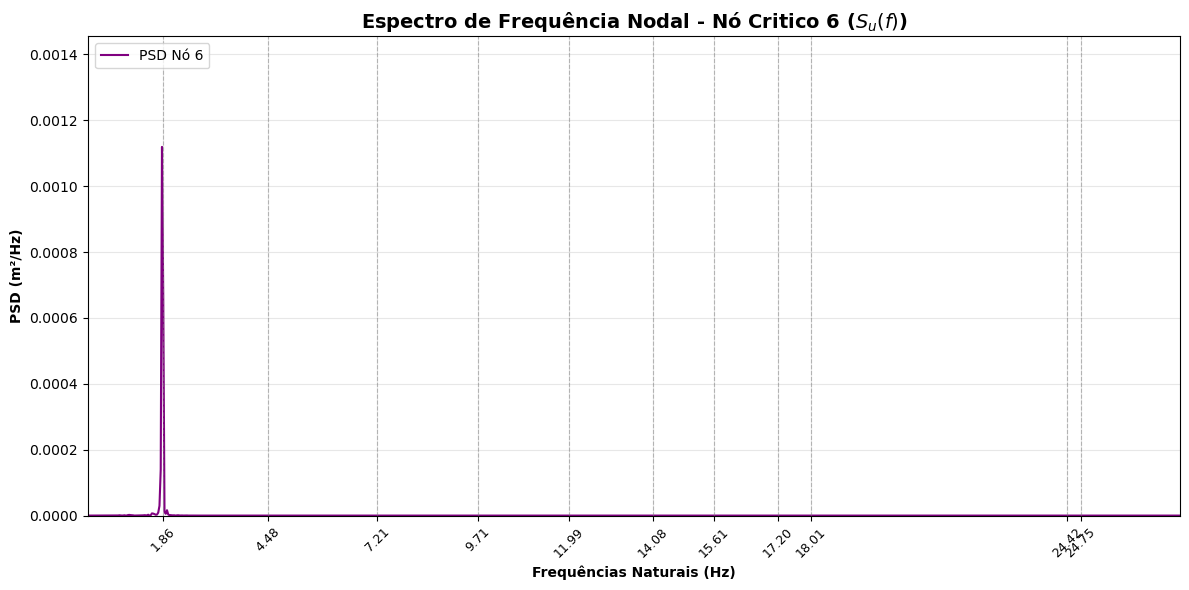

In [10]:
# 1. Cálculo da Densidade Espectral (PSD)
S, _ = uN.periodogram()  # Ignoramos o retorno de frequência que deu erro

# 2. Criar o eixo de frequências CORRETO manualmente
# S.shape[1] é a quantidade de pontos (4097)
# uN.fs é a taxa de amostragem que veio do arquivo do terremoto
f_axis = np.linspace(0, uN.fs/2, S.shape[1])

# 3. Definição do índice do Nó 6 (índice 5 no Python)
i = 5 

plt.figure(figsize=(12, 6))

# Agora o f_axis e o S[i, :] terão exatamente o mesmo tamanho
plt.plot(f_axis, S[i, :], color='purple', linewidth=1.5, label=f'PSD Nó {i+1}')

# --- O restante do seu código de plotagem segue igual ---
for freq in fk:
    plt.axvline(freq, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.xticks(fk, [f"{val:.2f}" for val in fk], rotation=45, fontsize=9)
s_max = np.max(S[i, :])
if s_max > 0: plt.ylim(0, s_max * 1.3)
plt.xlim(0, max(fk) * 1.1)
plt.title(f'Espectro de Frequência Nodal - Nó Critico {i+1} ($S_u(f)$)', fontsize=14, fontweight='bold')
plt.ylabel('PSD (m²/Hz)', fontsize=10, fontweight='bold')
plt.xlabel('Frequências Naturais (Hz)', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Calibração e Expansão das Matrizes (T.M.D.)

In [11]:
# =============================================================================
# IMPLEMENTAÇÃO DO T.M.D. (12º Grau de Liberdade)
# =============================================================================

# 1. Parâmetros de Calibração (Otimizados para Sismo)
mu = 0.05  # Aumentado para 5% (Capacidade muito maior de absorver a energia do sismo)
m_total = np.trace(M)
m_t = mu * m_total

w1 = wk[0] 
# Fator de sintonia ótimo para excitação de banda larga / sismo (Warburton)
f_opt = (np.sqrt(1 - mu/2)) / (1 + mu) 
wt = w1 * f_opt
kt = m_t * (wt**2)

# O amortecimento ótimo do TMD (ct) exigiria análise em modos complexos (State-Space).
# Para manter a compatibilidade com a superposição modal clássica do MRPy que você já usa,
# vamos acoplar as matrizes M e K, extrair os 12 novos modos reais e adotar a mesma 
# taxa de amortecimento modal (1%) para o novo sistema. O efeito de mitigação virá da 
# divisão do pico de massa modal (mass-splitting).

# 2. Expansão da Matriz de Massa (12x12)
M_tmd = np.zeros((12, 12))
M_tmd[:11, :11] = M
M_tmd[11, 11] = m_t

# 3. Expansão da Matriz de Rigidez (12x12)
K_tmd = np.zeros((12, 12))
K_tmd[:11, :11] = K

no_alvo = 5  # Nó 6 (índice 5), identificado como crítico anteriormente

# Acoplamento da mola kt entre o Nó 6 e o TMD
K_tmd[no_alvo, no_alvo] += kt
K_tmd[no_alvo, 11] = -kt
K_tmd[11, no_alvo] = -kt
K_tmd[11, 11] = kt

# 4. Solução do Novo Problema de Autovalores (12 GDLs)
w2_tmd, Phi_tmd = sc.eigh(K_tmd, M_tmd)
iw_tmd  = w2_tmd.argsort()
w2_tmd  = w2_tmd[iw_tmd]
Phi_tmd = Phi_tmd[:, iw_tmd]

wk_tmd = np.sqrt(np.real(w2_tmd))
fk_tmd = wk_tmd / (2 * np.pi)

print(f"Frequências Naturais com TMD acoplado: \n{np.round(fk_tmd, 2)} Hz")

Frequências Naturais com TMD acoplado: 
[ 1.54  2.1   4.48  7.23  9.71 12.   14.08 15.62 17.2  18.02 24.42 24.75] Hz


                                            MATRIZ DE RIGIDEZ EXPANDIDA COM T.M.D. (12x12) [N/m]                                            
[[1.1603E+08 -3.0587E+07 2.3027E+06 2.0738E+06 4.5423E+05 7.4859E+05 2.2280E+05 4.6472E+05 -3.6420E+05 -3.7597E+05 1.6475E+06 0.0000E+00]
 [-3.0587E+07 6.3140E+07 -3.3466E+07 7.0139E+04 4.4650E+05 7.1292E+04 3.3744E+05 9.8605E+02 1.3367E+04 3.4905E+05 -3.7597E+05 0.0000E+00]
 [2.3027E+06 -3.3466E+07 6.3190E+07 -3.3781E+07 1.4292E+06 -3.2332E+05 1.0826E+05 3.6961E+05 2.1185E+05 1.3367E+04 -3.6420E+05 0.0000E+00]
 [2.0738E+06 7.0139E+04 -3.3781E+07 6.4880E+07 -3.5494E+07 1.6671E+06 5.6432E+05 -2.1721E+05 3.6961E+05 9.8605E+02 4.6472E+05 0.0000E+00]
 [4.5423E+05 4.4650E+05 1.4292E+06 -3.5494E+07 6.5189E+07 -3.3698E+07 1.1654E+05 5.6432E+05 1.0826E+05 3.3744E+05 2.2280E+05 0.0000E+00]
 [7.4859E+05 7.1292E+04 -3.2332E+05 1.6671E+06 -3.3698E+07 6.3714E+07 -3.3698E+07 1.6671E+06 -3.2332E+05 7.1292E+04 7.4859E+05 -6.1542E+05]
 [2.2280E+05 3.3744E+05 1.082

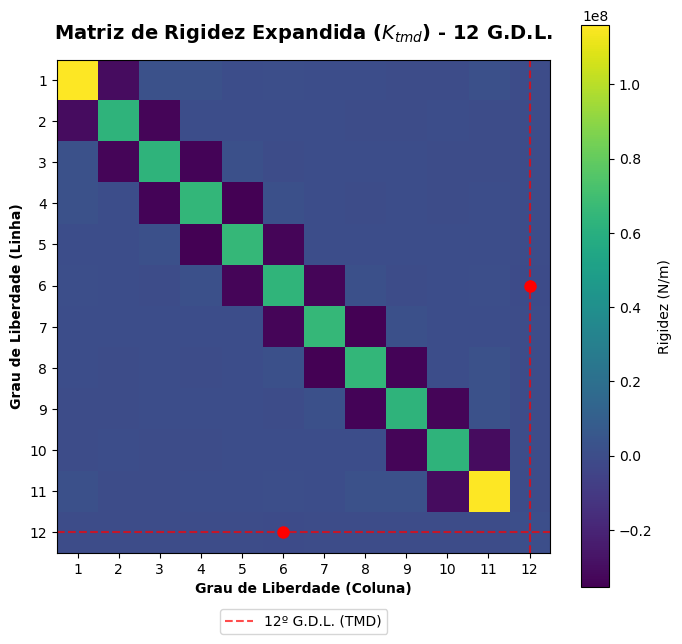

In [12]:
# =============================================================================
# EXTRAÇÃO E VISUALIZAÇÃO DA NOVA MATRIZ DE RIGIDEZ (K_tmd)
# =============================================================================

# 1. Impressão dos valores numéricos no console
# Configura o NumPy para notação científica (4 casas decimais) e não quebrar linhas
np.set_printoptions(linewidth=200, formatter={'float': lambda x: f"{x:.4E}"})

print("="*140)
print(f"{'MATRIZ DE RIGIDEZ EXPANDIDA COM T.M.D. (12x12) [N/m]':^140}")
print("="*140)
print(K_tmd) # O np.round foi removido pois o formatter já controla as casas
print("="*140)

# Restaura o print normal do NumPy para não afetar outras células acidentalmente
np.set_printoptions(formatter=None)

# 2. Visualização Gráfica (Heatmap)
plt.figure(figsize=(7, 6.5)) # Altura levemente aumentada para acomodar a legenda embaixo

# Plotagem da matriz
plt.imshow(K_tmd, cmap='viridis')
plt.title('Matriz de Rigidez Expandida ($K_{tmd}$) - 12 G.D.L.', fontsize=14, fontweight='bold', pad=15)
plt.colorbar(label='Rigidez (N/m)')

# Destaque visual para mostrar onde o TMD foi acoplado
# As linhas vermelhas interceptarão o nó alvo (índice 5) e o TMD (índice 11)
plt.axhline(11, color='red', linestyle='--', alpha=0.7, label='12º G.D.L. (TMD)')
plt.axvline(11, color='red', linestyle='--', alpha=0.7)
plt.plot(no_alvo, 11, 'ro', markersize=8) # Ponto de acoplamento K(11, 5)
plt.plot(11, no_alvo, 'ro', markersize=8) # Ponto de acoplamento K(5, 11)

# Ajuste de eixos
plt.xticks(np.arange(12), np.arange(1, 13))
plt.yticks(np.arange(12), np.arange(1, 13))
plt.xlabel('Grau de Liberdade (Coluna)', fontsize=10, fontweight='bold')
plt.ylabel('Grau de Liberdade (Linha)', fontsize=10, fontweight='bold')

# --- ALTERAÇÃO AQUI: Posição da legenda ---
# Movida para baixo do eixo X (centro)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=True)

plt.tight_layout()
plt.show()

                                             MATRIZ DE MASSA EXPANDIDA COM T.M.D. (12x12) [kg]                                              
[[   5096.84       0.00       0.00       0.00       0.00       0.00       0.00       0.00       0.00       0.00       0.00       0.00]
 [      0.00   10193.68       0.00       0.00       0.00       0.00       0.00       0.00       0.00       0.00       0.00       0.00]
 [      0.00       0.00   10193.68       0.00       0.00       0.00       0.00       0.00       0.00       0.00       0.00       0.00]
 [      0.00       0.00       0.00   10193.68       0.00       0.00       0.00       0.00       0.00       0.00       0.00       0.00]
 [      0.00       0.00       0.00       0.00   10193.68       0.00       0.00       0.00       0.00       0.00       0.00       0.00]
 [      0.00       0.00       0.00       0.00       0.00   10193.68       0.00       0.00       0.00       0.00       0.00       0.00]
 [      0.00       0.00       0.00       0.00    

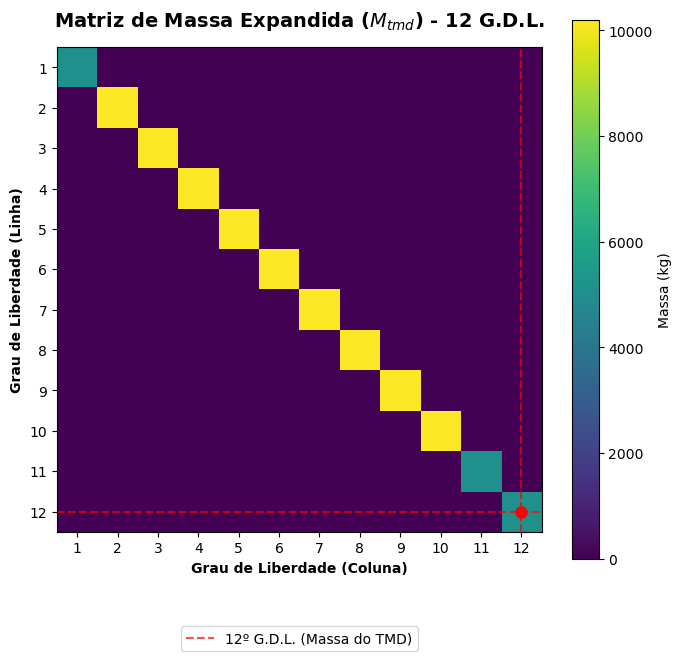

In [13]:
# =============================================================================
# EXTRAÇÃO E VISUALIZAÇÃO DA NOVA MATRIZ DE MASSA (M_tmd)
# =============================================================================

# 1. Impressão dos valores numéricos no console
# Configura o NumPy para formatar os valores com 2 casas decimais e alinhar as colunas
np.set_printoptions(linewidth=200, formatter={'float': lambda x: f"{x:10.2f}"})

print("="*140)
print(f"{'MATRIZ DE MASSA EXPANDIDA COM T.M.D. (12x12) [kg]':^140}")
print("="*140)
print(M_tmd)
print("="*140)

# Restaura a formatação padrão do NumPy para não afetar outras células
np.set_printoptions(formatter=None)

# 2. Visualização Gráfica (Heatmap)
plt.figure(figsize=(7, 6.5)) 

# Plotagem da matriz
# Como a matriz é diagonal, a maior parte do gráfico será da cor base do 'viridis' (representando o zero)
plt.imshow(M_tmd, cmap='viridis')
plt.title('Matriz de Massa Expandida ($M_{tmd}$) - 12 G.D.L.', fontsize=14, fontweight='bold', pad=15)
plt.colorbar(label='Massa (kg)')

# Destaque visual para mostrar onde a massa do TMD foi alocada
# As linhas vermelhas cruzarão exatamente a posição M(12, 12)
plt.axhline(11, color='red', linestyle='--', alpha=0.7, label='12º G.D.L. (Massa do TMD)')
plt.axvline(11, color='red', linestyle='--', alpha=0.7)
plt.plot(11, 11, 'ro', markersize=8) # Ponto correspondente a m_t

# Ajuste de eixos
plt.xticks(np.arange(12), np.arange(1, 13))
plt.yticks(np.arange(12), np.arange(1, 13))
plt.xlabel('Grau de Liberdade (Coluna)', fontsize=10, fontweight='bold')
plt.ylabel('Grau de Liberdade (Linha)', fontsize=10, fontweight='bold')

# Legenda posicionada abaixo do eixo X
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=True)

plt.tight_layout()
plt.show()

### Resposta Dinâmica do Sistema com T.M.D.

In [14]:
# =============================================================================
# RESPOSTA DINÂMICA DO NOVO SISTEMA COM T.M.D.
# =============================================================================

# 1. Normalização Modal pela Massa (12 Modos)
Mk_diag_tmd = np.dot(Phi_tmd.T, np.dot(M_tmd, Phi_tmd))
for k in range(12):
    Phi_tmd[:, k] = Phi_tmd[:, k] / np.sqrt(Mk_diag_tmd[k, k])

Mk_norm_tmd = np.dot(Phi_tmd.T, np.dot(M_tmd, Phi_tmd))
Mk_tmd = np.diag(Mk_norm_tmd)

# 2. Excitação Sísmica (Aplicada apenas aos GDLs estruturais, o TMD não recebe força externa direta)
# Vetor de influência: 1 para GDLs da estrutura, 0 para o TMD
r_inf = np.ones(12)
r_inf[11] = 0 

FG_data_tmd = -np.dot(M_tmd, np.outer(r_inf, aG[0]))
FG_tmd = MRPy(FG_data_tmd, fs=aG.fs)

# 3. Resolução no Espaço Modal
Fk_tmd = MRPy(np.dot(Phi_tmd.T, FG_tmd), fs=FG_tmd.fs)
ak_tmd = MRPy(np.dot(np.diag(1/Mk_tmd), Fk_tmd), fs=Fk_tmd.fs)

# Assumindo amortecimento modal constante de 1% para a estrutura, 
# mas calculando e injetando o amortecimento ótimo do TMD nos modos governantes
zt_tmd = np.full(12, 0.01) 

# Cálculo da taxa de amortecimento ótimo do TMD (aprox. 11% para mu=0.05)
zeta_opt = np.sqrt((mu * (1 - mu/4)) / (4 * (1 + mu) * (1 - mu/2)))

# Os modos 1 e 2 do novo sistema são os modos acoplados resultantes do TMD.
# Atribuímos a alta capacidade de dissipação do amortecedor a esses modos:
zt_tmd[0] = zeta_opt 
zt_tmd[1] = zeta_opt 

uk_tmd = ak_tmd.sdof_Duhamel(fk_tmd, zt_tmd)

# =============================================================================
# 4. TRANSFORMAÇÃO PARA O ESPAÇO NODAL (LINHA QUE ESTAVA FALTANDO)
# =============================================================================
uN_tmd = MRPy(np.dot(Phi_tmd, uk_tmd), fs=uk_tmd.fs)

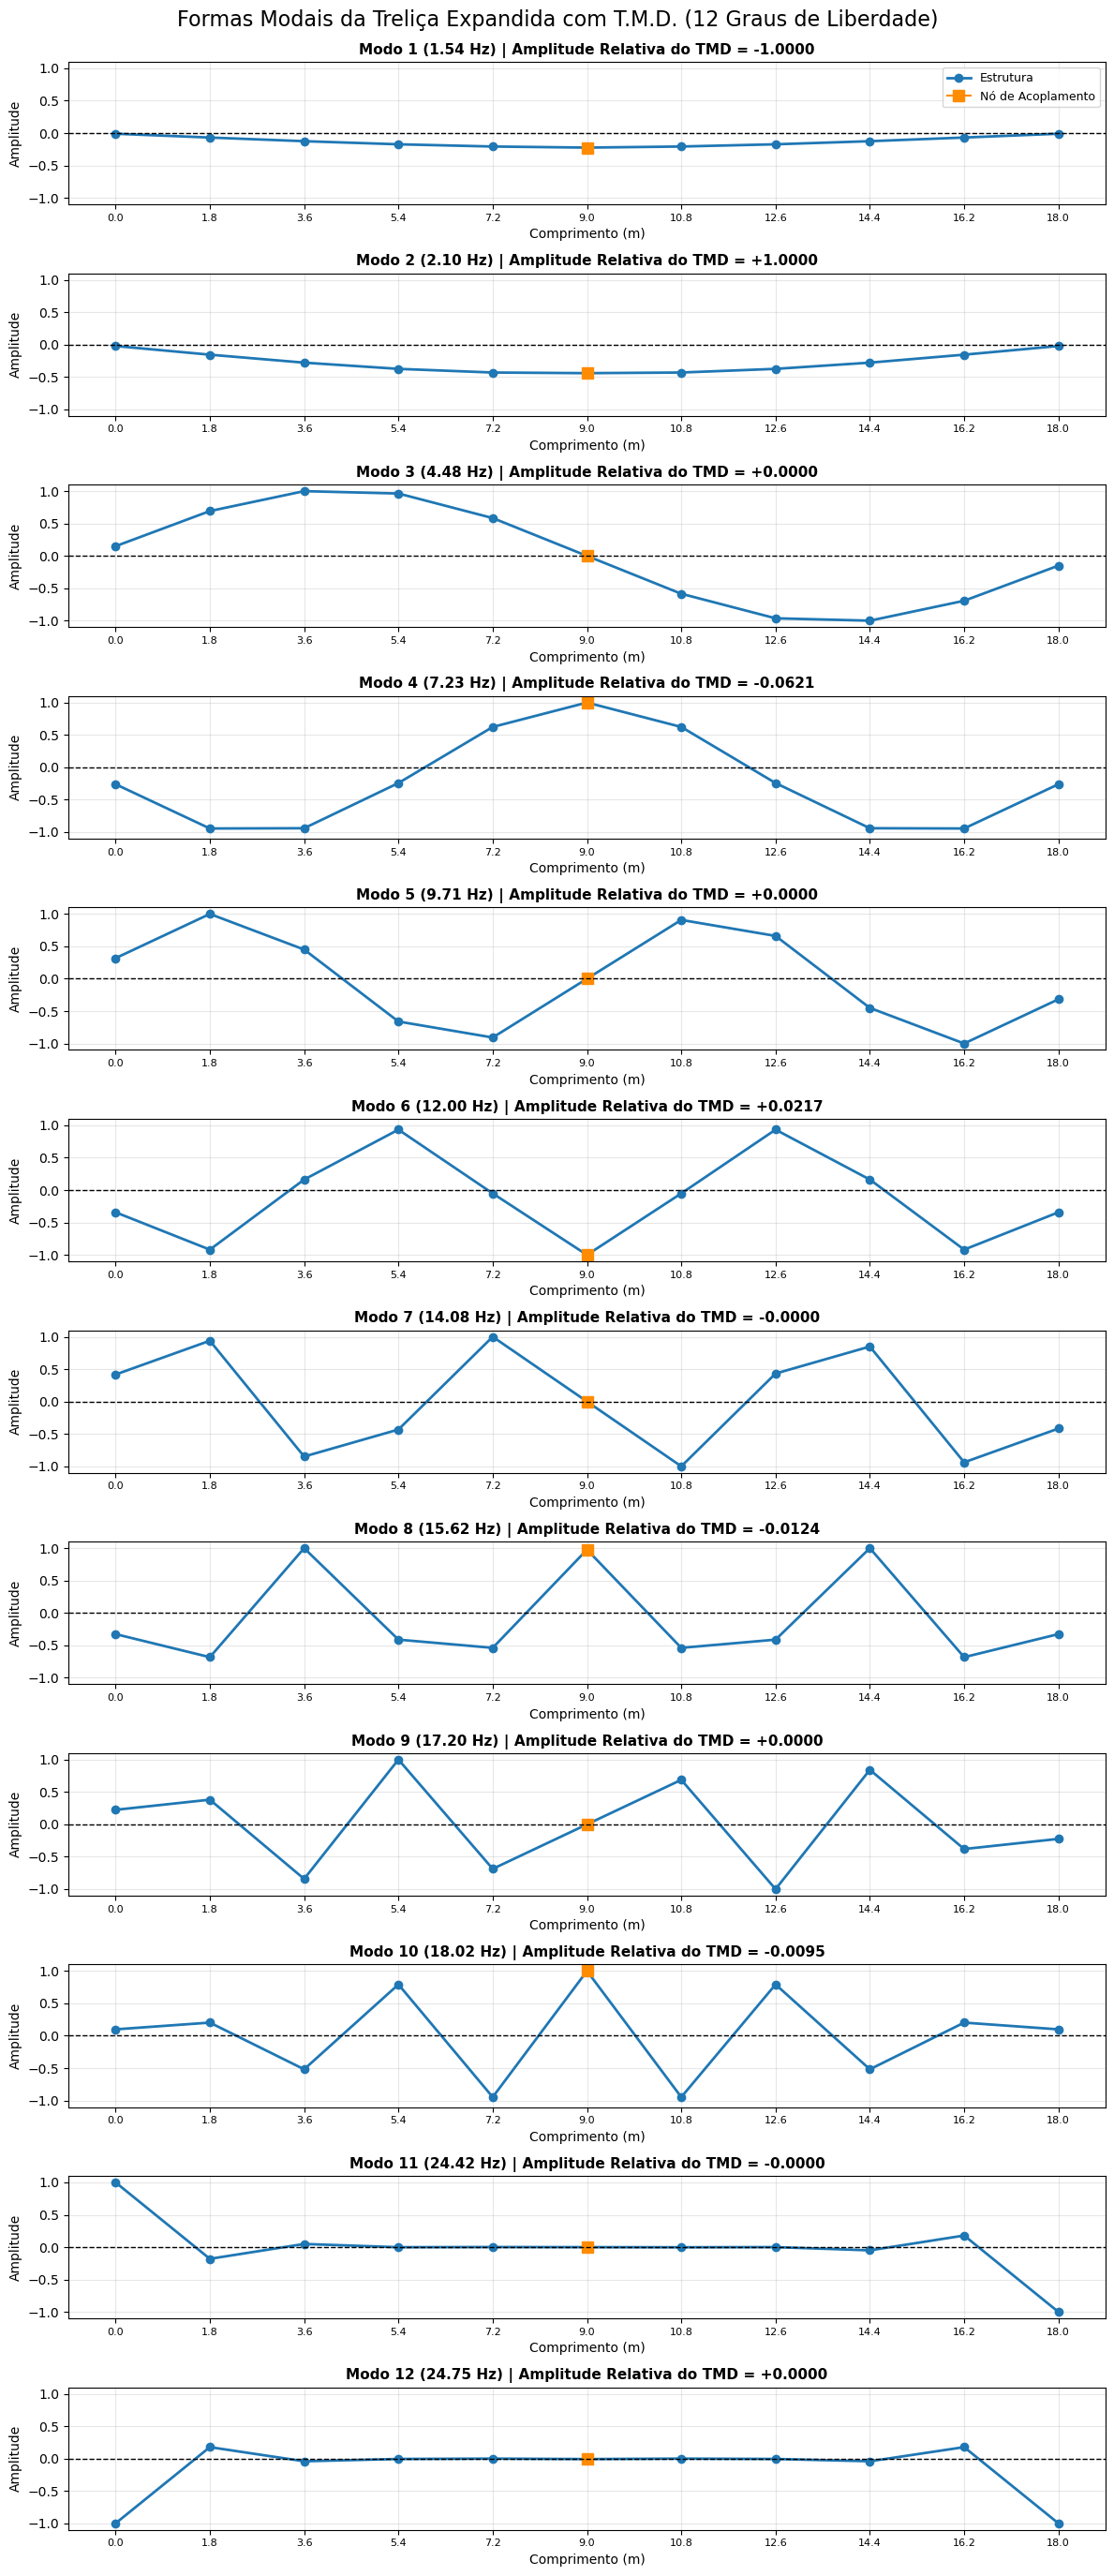

In [15]:
# =============================================================================
# VISUALIZAÇÃO GRÁFICA DAS NOVAS FORMAS MODAIS COM T.M.D. (12 G.D.L.)
# =============================================================================

# Coordenadas X exatas dos 11 nós estruturais do banzo superior
x_nos = np.linspace(0.0, 18.0, 11)

# Criando 12 gráficos empilhados verticalmente (12 linhas, 1 coluna)
# Aumentamos a altura proporcionalmente (para 28) para manter o espaçamento ideal
fig, axes = plt.subplots(12, 1, figsize=(12, 28))
fig.suptitle('Formas Modais da Treliça Expandida com T.M.D. (12 Graus de Liberdade)', fontsize=16, y=0.98)

for i in range(12):
    # --- Lógica de escala da aula ---
    # Normaliza a amplitude considerando todos os 12 elementos do autovetor
    qk_total = Phi_tmd[:, i].copy()
    qk_total /= np.max(np.abs(qk_total))
    
    # Separação: os primeiros 11 elementos vão para a linha da treliça
    qk_estrutura = qk_total[:11]
    # O 12º elemento (índice 11) é a amplitude relativa do próprio TMD
    qk_tmd_isolado = qk_total[11]
    
    # Plotando a deformada da estrutura (11 nós físicos)
    axes[i].plot(x_nos, qk_estrutura, marker='o', linestyle='-', color='#1f77b4', linewidth=2, label='Estrutura')
    
    # Destaca graficamente o Nó 6 (índice 5) onde o TMD está conectado
    axes[i].plot(x_nos[5], qk_estrutura[5], marker='s', color='darkorange', markersize=8, label='Nó de Acoplamento')
    
    # Configuração de títulos incluindo a amplitude do TMD para análise da eficiência
    axes[i].set_title(f'Modo {i+1} ({fk_tmd[i]:.2f} Hz) | Amplitude Relativa do TMD = {qk_tmd_isolado:+.4f}', 
                      fontsize=11, fontweight='bold')
    
    axes[i].axhline(0, color='black', linewidth=1, linestyle='--') # Eixo neutro
    axes[i].set_ylim(-1.1, 1.1)
    axes[i].set_xticks(x_nos)
    axes[i].tick_params(axis='x', labelsize=8)
    
    axes[i].set_xlabel('Comprimento (m)')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)
    
    # Adiciona legenda apenas no primeiro gráfico para não poluir
    if i == 0:
        axes[i].legend(loc='upper right', fontsize=9)

plt.tight_layout()
# Ajuste do topo para o título principal não encostar no primeiro gráfico
plt.subplots_adjust(top=0.96) 
plt.show()

### Visualização do PSD Normalizado (Sem T.M.D. vs. Com T.M.D.)

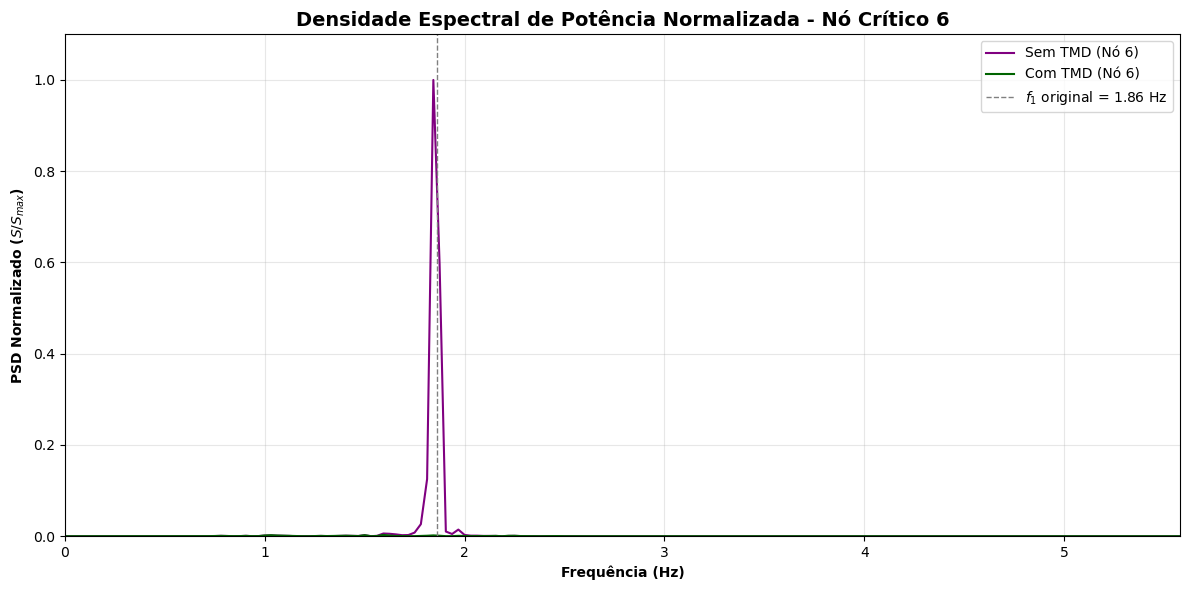

Redução de pico de energia no espectro (PSD): 99.72%


In [16]:
# =============================================================================
# COMPARAÇÃO DO PSD NORMALIZADO (NÓ CRÍTICO)
# =============================================================================

# Cálculo das Densidades Espectrais (Original e Com TMD)
S_orig, _ = uN.periodogram()
S_tmd, _  = uN_tmd.periodogram()

# Eixos de frequência (utilizando o tamanho correto do retorno)
f_axis_orig = np.linspace(0, uN.fs/2, S_orig.shape[1])
f_axis_tmd  = np.linspace(0, uN_tmd.fs/2, S_tmd.shape[1])

i = 5 # Nó 6 (Crítico)

# Fator de normalização (Pico máximo do nó crítico na estrutura original)
S_max_orig = np.max(S_orig[i, :])

# Normalizando os espectros
S_orig_norm = S_orig[i, :] / S_max_orig
S_tmd_norm  = S_tmd[i, :] / S_max_orig

plt.figure(figsize=(12, 6))

# Plotagem comparativa
plt.plot(f_axis_orig, S_orig_norm, color='purple', linewidth=1.5, label=f'Sem TMD (Nó {i+1})')
plt.plot(f_axis_tmd, S_tmd_norm, color='darkgreen', linewidth=1.5, label=f'Com TMD (Nó {i+1})')

# Destaque para a frequência fundamental original
plt.axvline(fk[0], color='gray', linestyle='--', linewidth=1.0, label=f'$f_1$ original = {fk[0]:.2f} Hz')

# Ajuste fino da visualização focada na ressonância principal
lim_freq = fk[0] * 3 # Exibe até 3x a frequência fundamental para foco
plt.xlim(0, lim_freq)
plt.ylim(0, 1.1)

plt.title(f'Densidade Espectral de Potência Normalizada - Nó Crítico {i+1}', fontsize=14, fontweight='bold')
plt.ylabel('PSD Normalizado ($S / S_{max}$)', fontsize=10, fontweight='bold')
plt.xlabel('Frequência (Hz)', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Imprime a redução alcançada
S_max_tmd = np.max(S_tmd_norm)
reducao = (1 - S_max_tmd) * 100
print(f"Redução de pico de energia no espectro (PSD): {reducao:.2f}%")

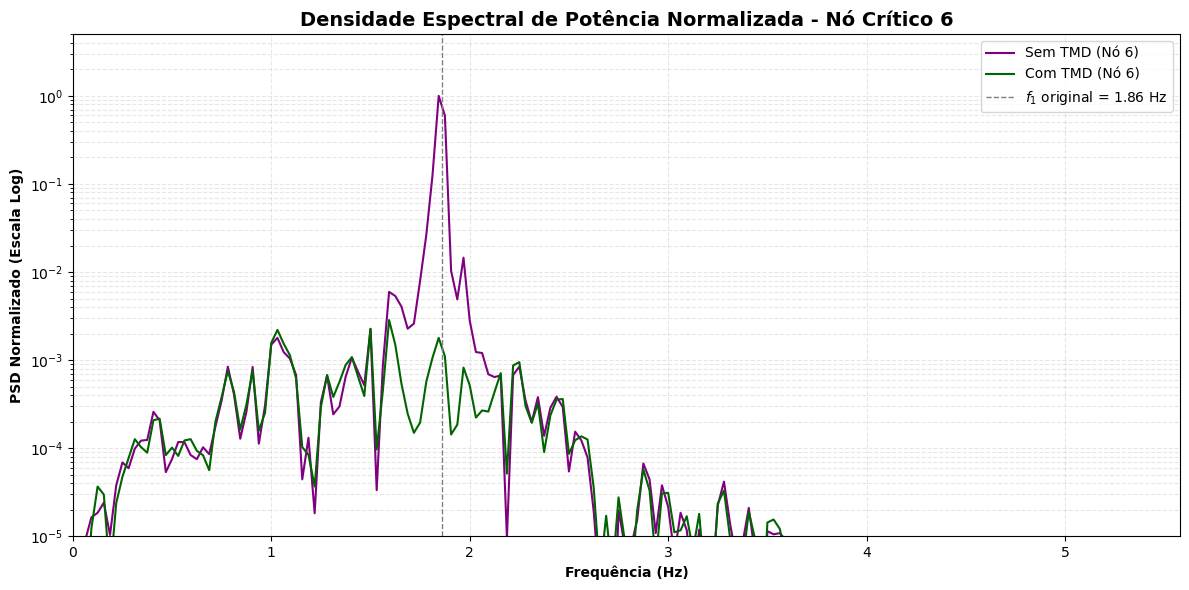

Redução de pico de energia no espectro (PSD): 99.72%


In [17]:
# =============================================================================
# COMPARAÇÃO DO PSD NORMALIZADO (NÓ CRÍTICO) - ESCALA LOGARÍTMICA
# =============================================================================

# Cálculo das Densidades Espectrais (Original e Com TMD)
S_orig, _ = uN.periodogram()
S_tmd, _  = uN_tmd.periodogram()

# Eixos de frequência
f_axis_orig = np.linspace(0, uN.fs/2, S_orig.shape[1])
f_axis_tmd  = np.linspace(0, uN_tmd.fs/2, S_tmd.shape[1])

i = 5 # Nó 6 (Crítico)

# Fator de normalização (Pico máximo do nó crítico na estrutura original)
S_max_orig = np.max(S_orig[i, :])

# Normalizando os espectros
S_orig_norm = S_orig[i, :] / S_max_orig
S_tmd_norm  = S_tmd[i, :] / S_max_orig

plt.figure(figsize=(12, 6))

# Plotagem comparativa
plt.plot(f_axis_orig, S_orig_norm, color='purple', linewidth=1.5, label=f'Sem TMD (Nó {i+1})')
plt.plot(f_axis_tmd, S_tmd_norm, color='darkgreen', linewidth=1.5, label=f'Com TMD (Nó {i+1})')

# Destaque para a frequência fundamental original
plt.axvline(fk[0], color='gray', linestyle='--', linewidth=1.0, label=f'$f_1$ original = {fk[0]:.2f} Hz')

# --- ALTERAÇÃO AQUI: Escala Logarítmica e Limites ---
plt.yscale('log')
plt.ylim(1e-5, 5) # Define o fundo do gráfico para 10^-5 e o topo um pouco acima de 10^0 (1)

lim_freq = fk[0] * 3 
plt.xlim(0, lim_freq)

plt.title(f'Densidade Espectral de Potência Normalizada - Nó Crítico {i+1}', fontsize=14, fontweight='bold')
plt.ylabel('PSD Normalizado (Escala Log)', fontsize=10, fontweight='bold')
plt.xlabel('Frequência (Hz)', fontsize=10, fontweight='bold')
plt.grid(True, which="both", ls="--", alpha=0.3) # Grid adaptado para escala log
plt.legend()
plt.tight_layout()
plt.show()

# Imprime a redução alcançada
S_max_tmd = np.max(S_tmd_norm)
reducao = (1 - S_max_tmd) * 100
print(f"Redução de pico de energia no espectro (PSD): {reducao:.2f}%")

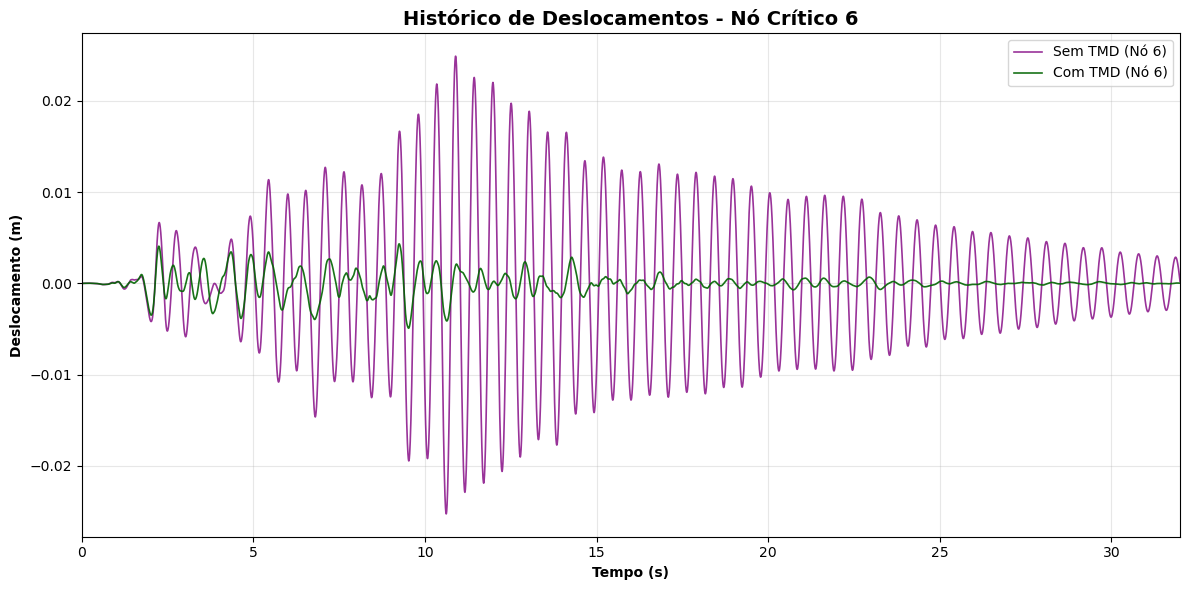

Flecha máxima SEM o T.M.D.: 2.489856e-02 m
Flecha máxima COM o T.M.D.: 4.332060e-03 m
Redução na flecha máxima: 82.60%


In [18]:
# =============================================================================
# COMPARAÇÃO DO HISTÓRICO DE DESLOCAMENTOS NO TEMPO (NÓ CRÍTICO)
# =============================================================================

i = 5  # Nó 6 (Crítico)

plt.figure(figsize=(12, 6))

# Plota a resposta do sistema original (Sem TMD)
plt.plot(t, uN[i, :], color='purple', linewidth=1.2, alpha=0.8, label=f'Sem TMD (Nó {i+1})')

# Plota a resposta do sistema modificado (Com TMD)
plt.plot(t, uN_tmd[i, :], color='darkgreen', linewidth=1.2, alpha=0.9, label=f'Com TMD (Nó {i+1})')

plt.title(f'Histórico de Deslocamentos - Nó Crítico {i+1}', fontsize=14, fontweight='bold')
plt.xlabel('Tempo (s)', fontsize=10, fontweight='bold')
plt.ylabel('Deslocamento (m)', fontsize=10, fontweight='bold')

# Limita o eixo X à duração do sismo
plt.xlim(0, aG.Td)

plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Imprime os valores de pico (flecha máxima descendente) para complementar o texto do relatório
pico_sem_tmd = np.max(uN[i, :])
pico_com_tmd = np.max(uN_tmd[i, :])
reducao_deslocamento = (1 - (pico_com_tmd / pico_sem_tmd)) * 100

print(f"Flecha máxima SEM o T.M.D.: {pico_sem_tmd:.6e} m")
print(f"Flecha máxima COM o T.M.D.: {pico_com_tmd:.6e} m")
print(f"Redução na flecha máxima: {reducao_deslocamento:.2f}%")

In [19]:
# =============================================================================
# RELATÓRIO DE PROPRIEDADES DO SISTEMA TMD
# =============================================================================

print("="*65)
print(f"{'PROPRIEDADES DO T.M.D. (OTIMIZADO PARA SISMO - WARBURTON)':^65}")
print("="*65)
print(f"{'Parâmetro':<40} | {'Valor Calculado':<20}")
print("-"*65)
print(f"{'Massa Total da Estrutura (M_tot)':<40} | {m_total:12.2f} kg")
print(f"{'Razão de Massa Adotada (mu)':<40} | {mu*100:12.2f} %")
print(f"{'Massa Absoluta do TMD (m_t)':<40} | {m_t:12.2f} kg")
print("-"*65)
print(f"{'Freq. Natural Fundamental (f_1)':<40} | {fk[0]:12.2f} Hz")
print(f"{'Freq. Angular Fundamental (w_1)':<40} | {w1:12.2f} rad/s")
print(f"{'Fator de Sintonia Ótimo (f_opt)':<40} | {f_opt:12.4f}")
print(f"{'Freq. Ótima do TMD (f_t)':<40} | {(wt/(2*np.pi)):12.2f} Hz")
print(f"{'Freq. Angular Ótima do TMD (w_t)':<40} | {wt:12.2f} rad/s")
print("-"*65)
print(f"{'Rigidez de Acoplamento (k_t)':<40} | {kt:12.2f} N/m")
print(f"{'Nó de Instalação (Grau de Liberdade)':<40} | Nó {no_alvo + 1} (GDL {no_alvo + 1})")
print(f"{'Amortecimento Ótimo do TMD (zeta_opt)':<40} | {zt_tmd[0]*100:12.2f} %")
print("="*65)

    PROPRIEDADES DO T.M.D. (OTIMIZADO PARA SISMO - WARBURTON)    
Parâmetro                                | Valor Calculado     
-----------------------------------------------------------------
Massa Total da Estrutura (M_tot)         |    101936.80 kg
Razão de Massa Adotada (mu)              |         5.00 %
Massa Absoluta do TMD (m_t)              |      5096.84 kg
-----------------------------------------------------------------
Freq. Natural Fundamental (f_1)          |         1.86 Hz
Freq. Angular Fundamental (w_1)          |        11.68 rad/s
Fator de Sintonia Ótimo (f_opt)          |       0.9404
Freq. Ótima do TMD (f_t)                 |         1.75 Hz
Freq. Angular Ótima do TMD (w_t)         |        10.99 rad/s
-----------------------------------------------------------------
Rigidez de Acoplamento (k_t)             |    615416.64 N/m
Nó de Instalação (Grau de Liberdade)     | Nó 6 (GDL 6)
Amortecimento Ótimo do TMD (zeta_opt)    |        10.98 %
